[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch07_workbook.ipynb)

# Decoding a trigram model

A trigram model gives the next word a probability from the two words before
it, and a decoder turns those probabilities into a text. Greedy decoding and
sampling commit to one word at a time; beam search keeps several partial texts
and chooses among them at the end.

In [1]:
#@title Setup: run this cell first
import functools
import os
import re
import urllib.request
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def need(ok, name, value, rule):
    if not ok: raise Refused(f"{name} is {value!r}, of type {type(value).__name__}: {rule}.")  # noqa: E701


# The words of a typed text, split as the novel is split; the last must occur in the novel.
def check(text):
    w = re.findall(r"[a-z]+(?:'[a-z]+)*", str(text).lower().replace("’", "'"))
    need(w and w[-1] in follow[()], "The text", text, "it must end on a word that occurs in the novel")
    return w


# The context the model reads: the last two words, or the last one when the
# novel never follows that pair with a word, or none.
def ctx(out):
    return next(c for c in (tuple(out[-2:]), tuple(out[-1:]), ()) if follow.get(c))


# The words the novel puts after the context c, likeliest first and ties in
# alphabetical order, and their probabilities P(w | c).
@functools.lru_cache(maxsize=None)
def table(c):
    ws = sorted(follow[c], key=lambda w: (-follow[c][w], w))
    n = np.array([follow[c][w] for w in ws], dtype=float)
    return ws, n / n.sum()


# How many of the likeliest words the nucleus keeps: the fewest whose
# probabilities sum to p or more.
def nucleus(q, p):
    need(isinstance(p, (int, float)) and 0 < p <= 1, "TOP_P", p, "it must be a number above 0, at most 1")
    return min(len(q), int(np.searchsorted(np.cumsum(q), p - 1e-9)) + 1)


# The start and n words after it: the likeliest word at temperature 0, else a
# draw from P^(1/temperature), cut to the k likeliest words or to the nucleus p.
def decode(start, n, temperature=0, k=None, p=None, rng=None):
    need(isinstance(temperature, (int, float)) and temperature >= 0, "T", temperature, "it must be a number, 0 or more")
    need(n in range(20001), "LENGTH", n, "it must be a whole number from 0 to 20,000")
    out = check(start)
    for _ in range(int(n)):
        ws, q = table(ctx(out))
        if temperature > 0:
            q = (q / q[0]) ** (1 / temperature)
            q = q[:nucleus(q / q.sum(), p) if p else k]
        out.append(ws[rng.choice(len(q), p=q / q.sum())] if temperature > 0 else ws[0])
    return out


# Beam search: the summed log probability and the words of the best hypothesis,
# keeping at every step the width hypotheses with the highest sum.
def beam(start, n, width):
    need(width in range(1, 1001), "B", width, "it must be a whole number from 1 to 1,000")
    beams = [(0.0, check(start))]
    for _ in range(n):
        cand = [(s + np.log(q), i, w) for i, (s, h) in enumerate(beams) for w, q in zip(*table(ctx(h)))]
        beams = [(s, beams[i][1] + [w]) for s, i, w in sorted(cand, key=lambda c: -c[0])[:int(width)]]
    return beams[0]


# For each word, whether the three-word phrase it ends occurred earlier in out.
def repeats(out):
    grams, first = [tuple(out[max(0, i - 2):i + 1]) for i in range(len(out))], {}
    for i, g in enumerate(grams):
        first.setdefault(g, i)
    return [i >= 2 and first[g] < i for i, g in enumerate(grams)]


def share(out):
    return sum(repeats(out)) / max(1, len(out) - 2)


# Words a to b of out, each word of a repeated three-word phrase in bold.
def marked(out, a=0, b=None):
    m = repeats(out)
    return " ".join(f"**{w}**" if any(m[j:j + 3]) else w for j, w in enumerate(out[a:b], a))


def show_texts(texts):
    display(Markdown("| | share repeated | text, repeated phrases in bold |\n| --- | ---: | --- |\n"
                     + "\n".join(f"| {k} | {share(o):.2f} | {marked(o)} |" for k, o in texts.items())))


# Bars of the likeliest words after the context: the nucleus solid, the words it cuts hatched.
def show_nucleus(context, p):
    ws, q = table(c := ctx(check(context)))
    m, shown = nucleus(q, p), min(len(q), 15)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    kept = f"nucleus: {m:,} of {len(q):,} words, probability {q[:m].sum():.2f}"
    kept += f", {shown} shown" if m > shown else ""
    for lo, hi, look in ((0, min(m, shown), dict(label=kept)),
                         (m, shown, dict(color="w", ec="C0", hatch="///", label="cut"))):
        if hi > lo:
            ax.bar_label(ax.barh(-np.arange(lo, hi), q[lo:hi], **look), fmt="%.3f", padding=3)
    ax.set_yticks(-np.arange(shown), ws[:shown])
    ax.set(xlabel=f"P(w | {' '.join(c)}), the probability of the next word", xlim=(0, 1.15 * q[0]))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False)
    plt.show()


chapters = load_novel()
tokens = [w for c in chapters for w in c]
follow = defaultdict(Counter)
for i, w in enumerate(tokens):
    for n in range(min(i, 2) + 1):
        follow[tuple(tokens[i - n:i])][w] += 1
# What step 1 last ran with to the end; the cells below read these.
start, length = "mr", 200
display(Markdown(f"{len(chapters)} chapters, {len(tokens):,} tokens and {len(follow[()]):,} word types."))

61 chapters, 122,174 tokens and 6,314 word types.

## 1. Greedy decoding runs into a loop

Greedy decoding appends the likeliest next word, one word at a time, and
takes the first in alphabetical order when words tie; bold marks each word of
a three-word phrase the text has already used. Run the cell, then put a start
of your own into `START` and run it again. At which word does the text begin
to repeat itself?

In [2]:
START = "mr"
LENGTH = 200
out = decode(START, LENGTH)
display(Markdown("| from word | text, repeated phrases in bold |\n| ---: | --- |\n"
                 + "\n".join(f"| {a + 1} | {marked(out, a, a + 10)} |" for a in range(0, len(out), 10))))
start, length = START, LENGTH

| from word | text, repeated phrases in bold |
| ---: | --- |
| 1 | mr darcy and her daughter and having examined his patient |
| 11 | said as little as possible and i am sure i |
| 21 | never saw such a man of large fortune and consequence |
| 31 | might do away at night she asked the chambermaid had |
| 41 | been so fortunate as to the door and called out |
| 51 | to her sister and bingley shall take no leave of |
| 61 | the family were assembled and where she was not in |
| 71 | the world and everybody began to be sure but else |
| 81 | i could not be able to make her a little |
| 91 | longer and elizabeth was forced to put it off again |
| 101 | but however he did not know what to think of |
| 111 | nothing else to do it without abhorrence we will go |
| 121 | as far **as** **to** **the** **door** **and** **called** **out** **to** |
| 131 | **her** **sister** **and** **bingley** **shall** **take** **no** **leave** **of** **the** |
| 141 | **family** **were** **assembled** **and** **where** **she** **was** **not** **in** **the** |
| 151 | **world** **and** **everybody** **began** **to** **be** **sure** **but** **else** **i** |
| 161 | **could** **not** **be** **able** **to** **make** **her** **a** **little** **longer** |
| 171 | **and** **elizabeth** **was** **forced** **to** **put** **it** **off** **again** **but** |
| 181 | **however** **he** **did** **not** **know** **what** **to** **think** **of** **nothing** |
| 191 | **else** **to** **do** **it** **without** **abhorrence** **we** **will** **go** **as** |
| 201 | **far** |

### Solution

In [3]:
f = repeats(long := decode(start, 2000)).index(True)
e = next(i for i in range(2, f) if long[i - 2:i + 1] == long[f - 2:f + 1])
end = len(check(start)) + length
after = "" if f < end else f"; the table ends at word {end}, before it"
display(Markdown(f"From \"{start}\", the first repeated phrase, \"{' '.join(long[f - 2:f + 1])}\", "
                 f"starts at word {f - 1}{after}. From there the text repeats the {f - e} words that "
                 f"began at word {e - 1} without end: each word depends on the two before it alone, "
                 f"and that pair of words has occurred before."))

From "mr", the first repeated phrase, "as to the", starts at word 123. From there the text repeats the 79 words that began at word 44 without end: each word depends on the two before it alone, and that pair of words has occurred before.

## 2. Sampling at a temperature

Sampling draws each next word at random in proportion to its probability. A
temperature `T` above 1 flattens the probabilities before the draw, and one
below 1 sharpens them. Run the cell, then set `T` to 0 and run it again. Does
any of the three samples repeat a phrase the way the greedy text does, and
what do the samples become at 0?

In [4]:
T = 1.2  # above 0 on purpose: sampling is the subject of this step
rng = np.random.default_rng(0)
samples = {f"sample {i + 1}": decode(start, length, temperature=T, rng=rng) for i in range(3)}
show_texts({"greedy": decode(start, length), **samples})

| | share repeated | text, repeated phrases in bold |
| --- | ---: | --- |
| greedy | 0.39 | mr darcy and her daughter and having examined his patient said as little as possible and i am sure i never saw such a man of large fortune and consequence might do away at night she asked the chambermaid had been so fortunate as to the door and called out to her sister and bingley shall take no leave of the family were assembled and where she was not in the world and everybody began to be sure but else i could not be able to make her a little longer and elizabeth was forced to put it off again but however he did not know what to think of nothing else to do it without abhorrence we will go as far **as** **to** **the** **door** **and** **called** **out** **to** **her** **sister** **and** **bingley** **shall** **take** **no** **leave** **of** **the** **family** **were** **assembled** **and** **where** **she** **was** **not** **in** **the** **world** **and** **everybody** **began** **to** **be** **sure** **but** **else** **i** **could** **not** **be** **able** **to** **make** **her** **a** **little** **longer** **and** **elizabeth** **was** **forced** **to** **put** **it** **off** **again** **but** **however** **he** **did** **not** **know** **what** **to** **think** **of** **nothing** **else** **to** **do** **it** **without** **abhorrence** **we** **will** **go** **as** **far** |
| sample 1 | 0.00 | mr wickham is blessed with such trifling exertion on his visits to his present assurances the happiness that might lead to the young man's marrying her sister you will believe that remaining partiality for their folly or their vice he was expected to affront anybody and everybody had been a selfish hypocritical woman and a good deal disappointed in not finding a letter from jane to go into company more than you ought to give the praise on the strength of his conduct in it but she contented herself with greater sweetness of address and expressions or the words which laid the foundation it is only evident that you have not many in which she expected her uncle and is i believe you were in the first tumult of elizabeth's feelings was perfectly unaware to her for it herself with such dreadful news which i acted she cried when shall we ask him how happy she would speak of the day i remain dear sir the disagreement subsisting between yourself and mr robinson did not scruple to call upon maria and hear her and more serious consequences my real purpose was to this effusion sensible that it was greatly my wish |
| sample 2 | 0.00 | mr collins had promised and as it would be consistent with his behaviour to mr darcy looked up to them might be alleviated on his returning no more than an error your superior knowledge of it all but she would to any young woman and very minutely to her and said all in pursuit of mr darcy's sister as to me on my poor mother is sadly grieved my father and though there were much too full for conversation she was able to show an abominable sort of preference which she was in all likelihood perfectly ignorant of their nature shall not deceive me i cannot give you no she would not even wish for in a line did i tell you among his daughters that the whole day or two when i expressed my hopes or fears i did not know anybody who seems more to be did you tell us of that my dear sir the garden he was regardless of the kind of girl she asked him at pemberley for a lady lives with her at length appear at least which was repeated to colonel forster repeat the particulars it is said that he told her to describe |
| sample 3 | 0.00 | mr darcy sends you all learn you ought certainly to his time there was now the object of that look was disputable it was impossible not to long to see it bingley replied that he thought he could have no horses to theirs i had better show more affection than she has seen me for it gratified him he is mercenary if you are gratifying mine both replied elizabeth archly for i am persuaded lasted no longer mortified by comparisons between her parents urged him so pleasant i can express charlotte assured her of good humour that on the day to make so very agreeable and sensible young man whom she did indeed louisa i could then perceive that her daughter colonel fitzwilliam and herself jane listened with an astonishment bordering on the monday fortnight but his father's lifetime there was one of her companion with a call from her thoughts and meditations which had never seen the rooms were lofty and handsome and amiable allowed encouraged almost taught me to entertain for him and herself his arrival but they did her mother's thoughts she supposed miss darcy was not very sanguine in expecting it the housekeeper was favourable to his |

### Solution

In [5]:
# The draws of step 2 again, from the same seed and the start step 1 last finished with.
rng = np.random.default_rng(0)
samples = {f"sample {i + 1}": decode(start, length, temperature=T, rng=rng) for i in range(3)}
k, greedy = len(check(start)), decode(start, length)
r = [f"{share(o):.2f}" for o in samples.values()]
ties = sum(q[1:2].sum() == q[0] for i in range(k, len(greedy)) for q in [table(ctx(greedy[:i]))[1]])
display(Markdown(f"At T = {T} the three samples repeat {r[0]}, {r[1]} and {r[2]} of their three-word "
                 f"phrases, the greedy text {share(greedy):.2f}. At {ties} of the greedy text's {length} "
                 f"steps two or more words tie as likeliest, and greedy decoding takes the first in "
                 f"alphabetical order" + (": at T = 0 the samples are the greedy text." if T == 0 else
                 ". A draw takes each tied word with the same probability, and a less likely word with less.")))

At T = 1.2 the three samples repeat 0.00, 0.00 and 0.00 of their three-word phrases, the greedy text 0.39. At 60 of the greedy text's 200 steps two or more words tie as likeliest, and greedy decoding takes the first in alphabetical order. A draw takes each tied word with the same probability, and a less likely word with less.

## 3. The distribution sets the size of the nucleus

Top-p sampling draws the next word from the nucleus: the likeliest words,
taken in order until their probabilities sum to `TOP_P` or more, with words of
equal probability taken in alphabetical order. Run the cell, then set
`CONTEXT` to "the" and run it again. How many words does the nucleus keep
after "mr", and how many after "the"?

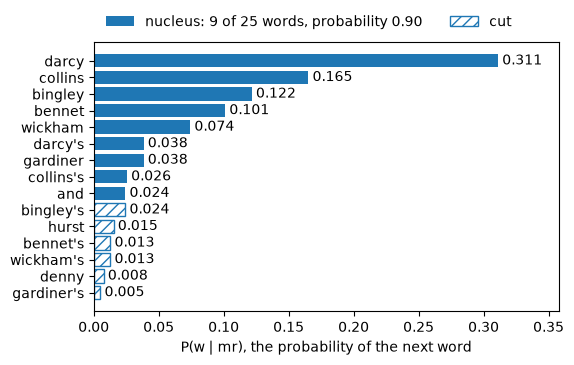

In [6]:
TOP_P = 0.9
CONTEXT = "mr"
show_nucleus(CONTEXT, TOP_P)

### Solution

In [7]:
kept = [f"{nucleus(table(c)[1], TOP_P):,} of the {len(table(c)[1]):,} words after \"{' '.join(c)}\""
        for c in dict.fromkeys([("mr",), ("the",), ctx(check(CONTEXT))])]
display(Markdown(f"At p = {TOP_P} the nucleus keeps {', '.join(kept[:-1])} and {kept[-1]}: the "
                 "probabilities set the size of the nucleus, and a top-k cut keeps k words after each."))

At p = 0.9 the nucleus keeps 9 of the 25 words after "mr" and 825 of the 1,258 words after "the": the probabilities set the size of the nucleus, and a top-k cut keeps k words after each.

## Appendix. Four decoders on one model

The trigram model predicts a word w from the two words u v before it,

P(w | u v) = count(u v w) / count(u v ·),

where count(u v ·) counts the times the novel follows the pair u v with a
word. After a single word, or after a pair the novel never follows, the model
reads the last word alone: P(w | v) = count(v w) / count(v ·).

- Greedy decoding appends w = argmax P(w | u v), the first in alphabetical
  order when words tie.
- Beam search keeps the B hypotheses with the highest score, score = Σ log
  P(wᵢ | wᵢ₋₂ wᵢ₋₁), extends each by every word the novel puts after its last
  two, and keeps the best B again. B = 1 is greedy decoding.
- Top-k sampling keeps the k likeliest words, rescales their probabilities to
  sum to 1 and draws one of them.
- Top-p sampling keeps the nucleus, the fewest likeliest words whose
  probabilities sum to p or more, rescales and draws.
- A temperature τ, `T` in step 2, reshapes the probabilities before any cut:
  P_τ(w | u v) = P(w | u v)^(1/τ) / Σ P(w′ | u v)^(1/τ). As τ → 0 the draw
  takes one of the likeliest words, each tied word with the same probability,
  where greedy decoding takes the first of them in alphabetical order; a large
  τ gives every word seen after u v nearly the same probability.

A pair of words the novel follows with one word alone gives that word
probability 1, and log 1 = 0 costs a hypothesis nothing. A beam can therefore
score higher by passing through rare pairs, each with a single follower, than
by taking the likeliest word at every step, and such a path can close into a
loop as greedy decoding does.

Repetition among the first n words of an output is the share of their
three-word phrases that occurred earlier in it. For n up to 300 words after
the start of step 1: greedy decoding and beam search with B = 5 and B = 50,
one output each, and top-k with k = 40 and top-p with p = 0.9 at τ = 1, the
mean of 10 samples each. Each line follows one output of 300 words through
its first n words, so a line falls where that output leaves a loop; a beam
run for n words alone can end on a different text.

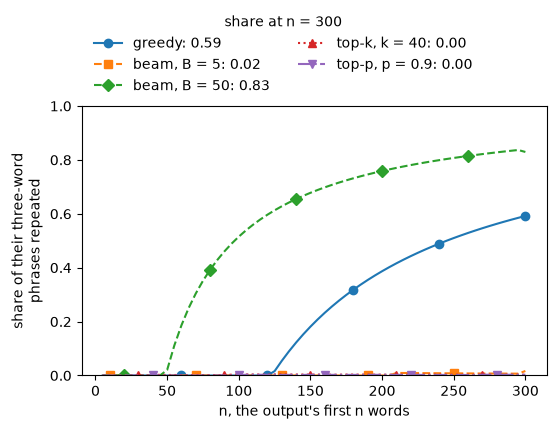

In [8]:
cut = dict(temperature=1.0, rng=np.random.default_rng(0))  # above 0: top-k and top-p sample
runs = {"greedy": [decode(start, 300)], **{f"beam, B = {b}": [beam(start, 300, b)[1]] for b in (5, 50)},
        "top-k, k = 40": [decode(start, 300, k=40, **cut) for _ in range(10)],
        "top-p, p = 0.9": [decode(start, 300, p=0.9, **cut) for _ in range(10)]}
k, ns = len(check(start)), range(5, 301, 5)
fig, ax = plt.subplots(figsize=(6, 3.5))
for (name, outs), style, first in zip(runs.items(), ("o-", "s--", "D--", "^:", "v-."), (11, 1, 3, 5, 7)):
    y = [np.mean([share(o[:k + n]) for o in outs]) for n in ns]
    ax.plot(ns, y, style, markevery=(first, 12), label=f"{name}: {y[-1]:.2f}")
ax.set(xlabel="n, the output's first n words", ylabel="share of their three-word\nphrases repeated", ylim=(0, 1))
ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False, title="share at n = 300")
plt.show()

**Exercise.** Set `B` to 1, 2, 5, 20, 50 and 200 in turn and rerun the cell.
Does a wider beam find 300 words the model scores higher, and at which widths
does the output repeat more than a tenth of its three-word phrases?

In [9]:
B = 5

score, best = beam(start, 300, B)
print(f"B = {B}: log probability {score:,.1f}, share repeated {share(best):.2f}")

B = 5: log probability -243.6, share repeated 0.02


### Solution

In [10]:
res = {b: (lp, share(o)) for b in (1, 2, 5, 20, 50, 200) for lp, o in [beam(start, 300, b)]}
display(Markdown("| B | log probability | share repeated |\n| ---: | ---: | ---: |\n"
                 + "\n".join(f"| {b} | {lp:,.1f} | {r:.2f} |" for b, (lp, r) in res.items())))
top, loops = max(res, key=lambda b: res[b][0]), [str(b) for b in res if res[b][1] > 0.1]
display(Markdown(f"B = 1 is greedy decoding, at log probability {res[1][0]:,.1f}; the highest "
                 f"score, {res[top][0]:,.1f}, comes from B = {top}. More than a tenth of the three-word "
                 f"phrases repeat at B = {', '.join(loops) or 'no width'}, and at no other width tried."))

| B | log probability | share repeated |
| ---: | ---: | ---: |
| 1 | -417.5 | 0.59 |
| 2 | -338.9 | 0.66 |
| 5 | -243.6 | 0.02 |
| 20 | -139.1 | 0.00 |
| 50 | -102.7 | 0.83 |
| 200 | -106.4 | 0.56 |

B = 1 is greedy decoding, at log probability -417.5; the highest score, -102.7, comes from B = 50. More than a tenth of the three-word phrases repeat at B = 1, 2, 50, 200, and at no other width tried.